# 02 - Exploratory Data Analysis

Looks at the cleaned data from Phase 1 to understand what we're working with before
building any features or models: how rare is laundering, does it look different by
payment format/currency/amount/time, and what do the known laundering patterns look like.

All charts are saved to `results/figures/`. The **Key findings** section at the end is
filled in after actually looking at the charts below, not written in advance.

In [13]:
import sys
import os
from pathlib import Path

# Make sure we're working from the project root (not the notebooks/ folder),
# so `from src... import ...` and every relative path in config.yaml resolve
# correctly no matter where Jupyter was started from.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import load_config

config = load_config(project_root / "config.yaml")
FIGURES_DIR = Path(config["paths"]["figures_dir"])
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(config["paths"]["clean_file"])
print(f"Loaded {len(df):,} rows")
df.head()

Loaded 253,917 rows


,timestamp,from_bank,from_account,to_bank,to_account,amount_received,receiving_currency,amount_paid,payment_currency,payment_format,is_laundering,from_id,to_id,is_self_transfer,amount_paid_usd,amount_received_usd,amount_usd
0,2022-09-01,121,8123FB9B0,121,8123FB9B0,47.64,Saudi Riyal,47.64,Saudi Riyal,Reinvestment,0,121_8123FB9B0,121_8123FB9B0,True,12.700275,12.700275,12.700275
1,2022-09-01,25170,8095AF7C0,25170,8095AF7C0,3917.42,Canadian Dollar,3917.42,Canadian Dollar,Reinvestment,0,25170_8095AF7C0,25170_8095AF7C0,True,2969.317062,2969.317062,2969.317062
2,2022-09-01,25665,809A7D4B0,24779,809189BA0,97.49,Canadian Dollar,97.49,Canadian Dollar,Credit Card,0,25665_809A7D4B0,24779_809189BA0,False,73.895247,73.895247,73.895247
3,2022-09-01,32317,800D4E490,12004,800D4E750,13939.05,Euro,13939.05,Euro,Wire,0,32317_800D4E490,12004_800D4E750,False,16333.548279,16333.548279,16333.548279
4,2022-09-01,1024,800C8D9D0,1024,800C8D9D0,10.37,Euro,10.37,Euro,Reinvestment,0,1024_800C8D9D0,1024_800C8D9D0,True,12.151395,12.151395,12.151395


## Chart colours

A small fixed set of colours is used everywhere in this notebook, instead of letting
matplotlib pick different colours on every chart. Blue always means "normal" and orange
always means "laundering" — keeping that pairing fixed makes charts easier to compare and
read at a glance.

In [26]:
COLOR_NORMAL = "#2a78d6"       # blue: normal transactions / accounts
COLOR_LAUNDERING = "#eb6834"   # orange: laundering transactions / accounts
COLOR_BAR = "#2a78d6"          # default single-series bar colour
COLOR_GRID = "#e1e0d9"
COLOR_TEXT = "#0b0b0b"
COLOR_MUTED = "#898781"


def style_axis(ax):
    """Plain, low-clutter chart style: no top/right border, light gridlines."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(colors=COLOR_MUTED)

## 1. Class imbalance

What fraction of transactions are actually laundering? This number matters a lot for
every later phase: if laundering is very rare, a model that just predicts "normal" every
single time can still score a very high accuracy while catching zero laundering — which is
exactly why accuracy isn't used as the main metric later (Phase 4 covers this properly).

The bar chart below uses a log scale on the y-axis, otherwise the laundering bar would be
too short to see next to the normal bar.

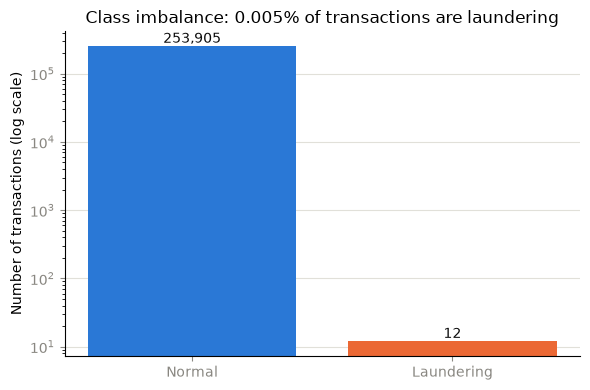

Laundering rate: 0.0047%


In [15]:
laundering_rate = df["is_laundering"].mean()
counts = df["is_laundering"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Normal", "Laundering"], counts.values, color=[COLOR_NORMAL, COLOR_LAUNDERING])
ax.set_yscale("log")
style_axis(ax)
ax.set_ylabel("Number of transactions (log scale)")
ax.set_title(f"Class imbalance: {laundering_rate:.3%} of transactions are laundering")
for bar, count in zip(bars, counts.values):
    ax.annotate(f"{count:,}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", color=COLOR_TEXT)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_class_imbalance.png", dpi=150)
plt.show()

print(f"Laundering rate: {laundering_rate:.4%}")

## 2. Laundering rate by payment format and currency

Some payment formats or currencies might be used disproportionately for laundering.
For currency, formats/currencies with very few transactions are excluded from the rate
chart — the same reasoning as Phase 1's "low confidence" flag on thin exchange rates: a
rate computed from only a handful of rows isn't trustworthy, even if the number itself
looks dramatic (e.g. 1 laundering row out of 3 total would show as a 33% rate).

In [16]:
def laundering_rate_by(data, col, min_count=0):
    """Laundering rate per category in `col`, dropping categories with fewer than min_count rows."""
    value_counts = data[col].value_counts()
    reliable = value_counts[value_counts >= min_count].index
    subset = data[data[col].isin(reliable)]
    return subset.groupby(col, observed=True)["is_laundering"].mean().sort_values(ascending=False)


def plot_rate_bar(rates, title, filename):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(rates.index[::-1].astype(str), rates.values[::-1], color=COLOR_BAR)
    style_axis(ax)
    ax.set_xlabel("Laundering rate")
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=150)
    plt.show()

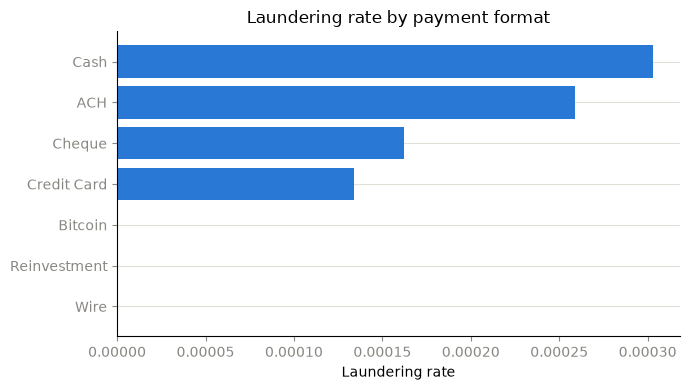

payment_format
Cash            0.000303
ACH             0.000259
Cheque          0.000162
Credit Card     0.000134
Bitcoin         0.000000
Reinvestment    0.000000
Wire            0.000000
Name: is_laundering, dtype: float64

In [17]:
rate_by_format = laundering_rate_by(df, "payment_format")
plot_rate_bar(rate_by_format, "Laundering rate by payment format", "02_laundering_rate_by_format.png")
rate_by_format

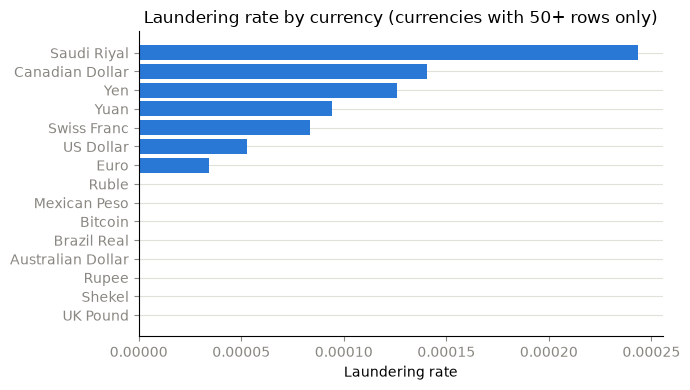

payment_currency
Saudi Riyal          0.000243
Canadian Dollar      0.000140
Yen                  0.000126
Yuan                 0.000094
Swiss Franc          0.000084
US Dollar            0.000053
Euro                 0.000034
Ruble                0.000000
Mexican Peso         0.000000
Bitcoin              0.000000
Brazil Real          0.000000
Australian Dollar    0.000000
Rupee                0.000000
Shekel               0.000000
UK Pound             0.000000
Name: is_laundering, dtype: float64

In [18]:
# min_count=50: same reliability threshold used for exchange rates in Phase 1
rate_by_currency = laundering_rate_by(df, "payment_currency", min_count=50)
plot_rate_bar(rate_by_currency, "Laundering rate by currency (currencies with 50+ rows only)", "03_laundering_rate_by_currency.png")
rate_by_currency

## 3. Amount distributions (log scale)

Comparing the amounts involved in laundering vs normal transactions. Two things to note
about the code below:

- **Log scale**: transaction amounts span many orders of magnitude (a few dollars up to
  billions, per the cleaning report), so a plain histogram would just show one tall spike
  near zero. Taking `log10(amount + 1)` compresses that range into something readable.
  (+1 avoids `log10(0)`, which is undefined.)
- **`density=True`**: laundering is a tiny fraction of all rows, so plotting raw counts
  would make the laundering histogram invisible next to the normal one. `density=True`
  rescales each histogram to show *shape* (where its mass sits) rather than raw count,
  so the two distributions can be compared directly.

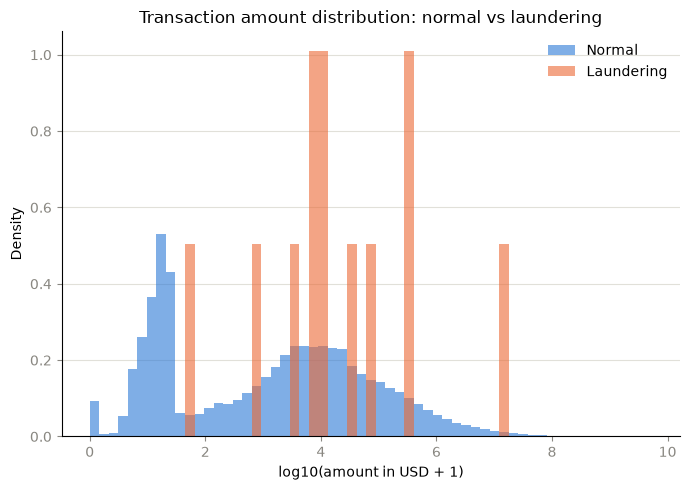

In [19]:
log_amount_normal = np.log10(df.loc[df["is_laundering"] == 0, "amount_usd"] + 1)
log_amount_laundering = np.log10(df.loc[df["is_laundering"] == 1, "amount_usd"] + 1)

bins = np.linspace(0, max(log_amount_normal.max(), log_amount_laundering.max()), 60)

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(log_amount_normal, bins=bins, density=True, alpha=0.6, color=COLOR_NORMAL, label="Normal")
ax.hist(log_amount_laundering, bins=bins, density=True, alpha=0.6, color=COLOR_LAUNDERING, label="Laundering")
style_axis(ax)
ax.set_xlabel("log10(amount in USD + 1)")
ax.set_ylabel("Density")
ax.set_title("Transaction amount distribution: normal vs laundering")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_amount_distribution.png", dpi=150)
plt.show()

## 4. Transactions and laundering over time

Two separate charts (never one chart with two different y-axes overlaid — that's an easy
way to accidentally mislead, since the two scales can be stretched to imply a relationship
that isn't really there).

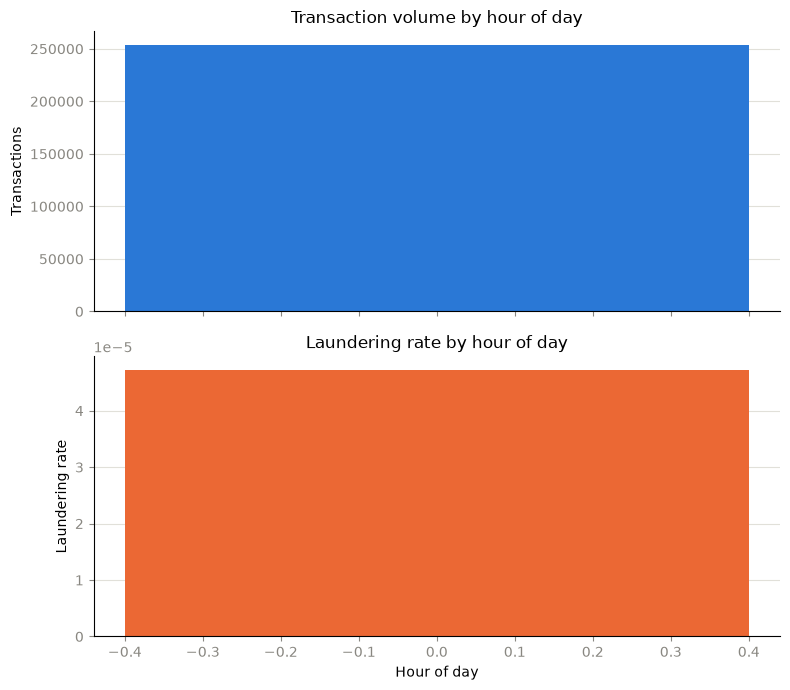

In [20]:
df["hour"] = df["timestamp"].dt.hour
df["date"] = df["timestamp"].dt.date

hourly = df.groupby("hour").agg(n_transactions=("is_laundering", "size"), n_laundering=("is_laundering", "sum"))
hourly["laundering_rate"] = hourly["n_laundering"] / hourly["n_transactions"]

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
axes[0].bar(hourly.index, hourly["n_transactions"], color=COLOR_BAR)
style_axis(axes[0])
axes[0].set_ylabel("Transactions")
axes[0].set_title("Transaction volume by hour of day")

axes[1].bar(hourly.index, hourly["laundering_rate"], color=COLOR_LAUNDERING)
style_axis(axes[1])
axes[1].set_ylabel("Laundering rate")
axes[1].set_xlabel("Hour of day")
axes[1].set_title("Laundering rate by hour of day")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_transactions_by_hour.png", dpi=150)
plt.show()

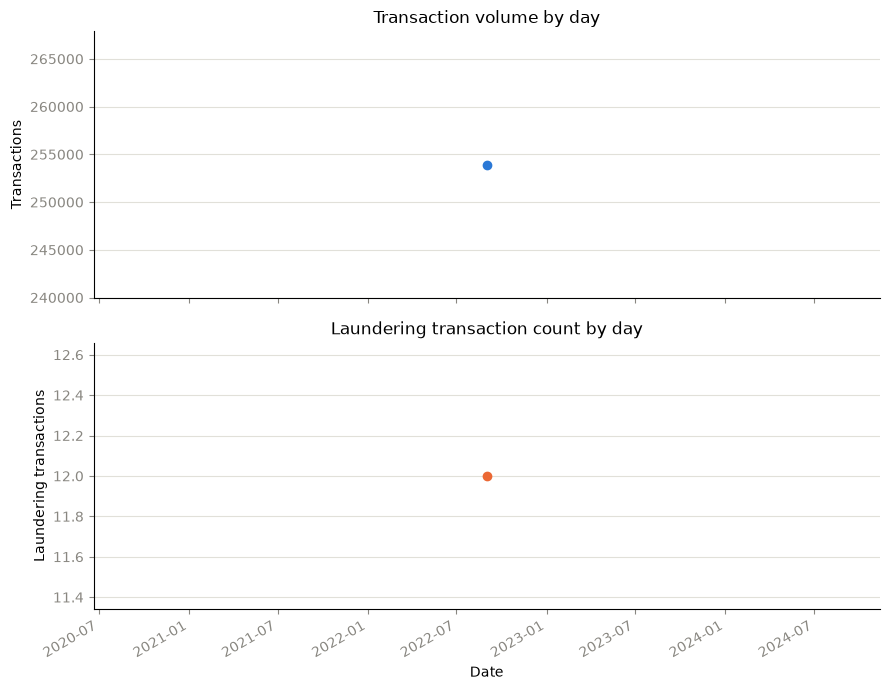

In [21]:
daily = df.groupby("date").agg(n_transactions=("is_laundering", "size"), n_laundering=("is_laundering", "sum"))

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].plot(daily.index, daily["n_transactions"], color=COLOR_BAR, linewidth=2, marker="o")
style_axis(axes[0])
axes[0].set_ylabel("Transactions")
axes[0].set_title("Transaction volume by day")

axes[1].plot(daily.index, daily["n_laundering"], color=COLOR_LAUNDERING, linewidth=2, marker="o")
style_axis(axes[1])
axes[1].set_ylabel("Laundering transactions")
axes[1].set_title("Laundering transaction count by day")
axes[1].set_xlabel("Date")

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_transactions_by_day.png", dpi=150)
plt.show()

## 5. Account activity

How active is an account (as sender or receiver, combined), and does that differ between
accounts that were ever involved in a laundering transaction vs accounts that never were?
Same log-scale + density reasoning as the amount distribution above.

In [22]:
# Combine sent and received transaction counts per account.
from_counts = df["from_id"].value_counts()
to_counts = df["to_id"].value_counts()
activity = from_counts.add(to_counts, fill_value=0)

# An account "involved in laundering" appeared as sender OR receiver on at least one
# laundering row. This is an account-level label, not a transaction-level one.
laundering_accounts = set(df.loc[df["is_laundering"] == 1, "from_id"]) | set(df.loc[df["is_laundering"] == 1, "to_id"])

activity_df = activity.rename("n_transactions").to_frame()
activity_df["involved_in_laundering"] = activity_df.index.isin(laundering_accounts)

print(f"Accounts involved in laundering: {len(laundering_accounts):,} of {len(activity_df):,} "
      f"({len(laundering_accounts) / len(activity_df):.2%})")

Accounts involved in laundering: 20 of 221,541 (0.01%)


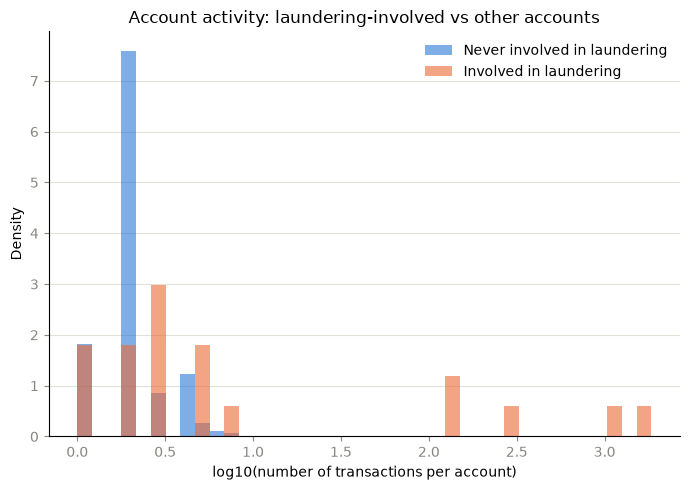

Median transactions per account -- involved in laundering: 3, others: 2


In [23]:
log_activity_normal = np.log10(activity_df.loc[~activity_df["involved_in_laundering"], "n_transactions"])
log_activity_laundering = np.log10(activity_df.loc[activity_df["involved_in_laundering"], "n_transactions"])

bins = np.linspace(0, max(log_activity_normal.max(), log_activity_laundering.max()), 40)

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(log_activity_normal, bins=bins, density=True, alpha=0.6, color=COLOR_NORMAL, label="Never involved in laundering")
ax.hist(log_activity_laundering, bins=bins, density=True, alpha=0.6, color=COLOR_LAUNDERING, label="Involved in laundering")
style_axis(ax)
ax.set_xlabel("log10(number of transactions per account)")
ax.set_ylabel("Density")
ax.set_title("Account activity: laundering-involved vs other accounts")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "07_account_activity.png", dpi=150)
plt.show()

normal_median = activity_df.loc[~activity_df["involved_in_laundering"], "n_transactions"].median()
laundering_median = activity_df.loc[activity_df["involved_in_laundering"], "n_transactions"].median()
print(f"Median transactions per account -- involved in laundering: {laundering_median:.0f}, others: {normal_median:.0f}")

## 6. Laundering patterns (`HI-Small_Patterns.txt`)

This file separately documents the actual laundering schemes the simulator generated
(fan-out, fan-in, cycles, etc.), each wrapped in a
`BEGIN LAUNDERING ATTEMPT - <PATTERN>` / `END LAUNDERING ATTEMPT - <PATTERN>` block. The
parser below counts how many attempts of each pattern exist, and how many individual
transactions make up each one.

**Note:** this parser was written and tested against a hand-made file with the same
BEGIN/END structure, since the real file wasn't available while writing this notebook. If
the table below comes out empty or looks wrong, the real file's format differs slightly —
flag that rather than trusting the chart, and we'll fix the parser together.

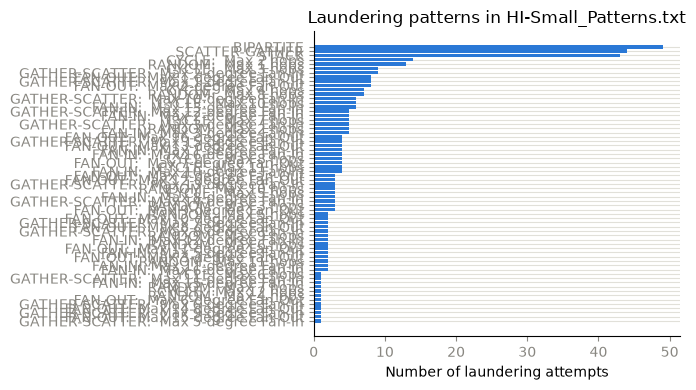

,n_attempts,n_transactions
BIPARTITE,49,263
SCATTER-GATHER,44,626
STACK,43,466
CYCLE: Max 2 hops,14,28
RANDOM: Max 1 hops,13,13
...,...,...
GATHER-SCATTER: Max 6-degree Fan-In,1,12
FAN-OUT: Max 14-degree Fan-Out,1,14
GATHER-SCATTER: Max 9-degree Fan-In,1,14
FAN-OUT: Max 15-degree Fan-Out,1,15


In [24]:
def summarize_patterns(path: Path) -> pd.DataFrame:
    pattern_counts = {}
    pattern_tx_counts = {}
    current_pattern = None
    current_tx = 0

    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("BEGIN LAUNDERING ATTEMPT"):
                current_pattern = line.split(" - ", 1)[-1].strip()
                current_tx = 0
            elif line.startswith("END LAUNDERING ATTEMPT"):
                if current_pattern is not None:
                    pattern_counts[current_pattern] = pattern_counts.get(current_pattern, 0) + 1
                    pattern_tx_counts[current_pattern] = pattern_tx_counts.get(current_pattern, 0) + current_tx
                current_pattern = None
            elif current_pattern is not None and line:
                current_tx += 1

    return pd.DataFrame({
        "n_attempts": pd.Series(pattern_counts),
        "n_transactions": pd.Series(pattern_tx_counts),
    }).sort_values("n_attempts", ascending=False)


patterns_file = Path(config["paths"]["patterns_file"])
pattern_summary = summarize_patterns(patterns_file)

if pattern_summary.empty:
    print("No patterns parsed -- the file format likely differs from what this parser expects.")
    print("Paste the first ~20 lines of HI-Small_Patterns.txt so the parser can be fixed.")
else:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(pattern_summary.index[::-1].astype(str), pattern_summary["n_attempts"][::-1], color=COLOR_BAR)
    style_axis(ax)
    ax.set_xlabel("Number of laundering attempts")
    ax.set_title("Laundering patterns in HI-Small_Patterns.txt")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "08_laundering_patterns.png", dpi=150)
    plt.show()

pattern_summary

## Key findings

<!-- TODO: fill in 3-5 plain-language findings after actually running the cells above
and looking at the real charts and numbers. Do not write these in advance. -->